<a href="https://colab.research.google.com/github/OhJin-Soo/Hands-On-Generative-AI/blob/main/Hands_On_Generative_AI_ch_2_Transformer_251021.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 생성 입문

In [1]:
from genaibook.core import get_device

device = get_device()
print(f"using device: {device}")

using device: cuda


In [2]:
import torch
from diffusers import StableDiffusionPipeline

pipe = StableDiffusionPipeline.from_pretrained(
    "stable-diffusion-v1-5/stable-diffusion-v1-5",
    torch_dtype = torch.float16,
    variant="fp16",
).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 15 files:   0%|          | 0/15 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

unet/diffusion_pytorch_model.fp16.safete(…):   0%|          | 0.00/1.72G [00:00<?, ?B/s]

vae/diffusion_pytorch_model.fp16.safeten(…):   0%|          | 0.00/167M [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

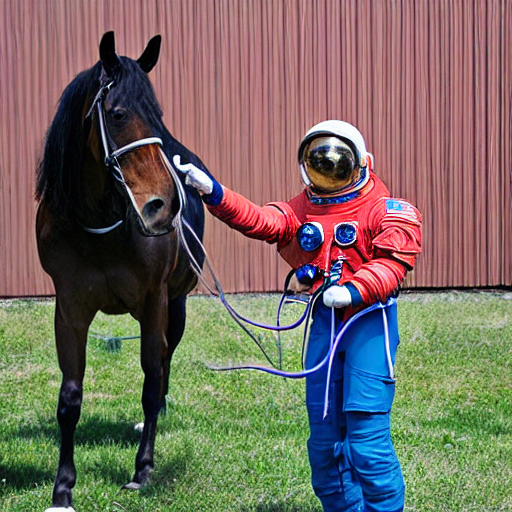

In [3]:
prompt = "a photograph of an astronaut riding a horse"
pipe(prompt).images[0]

In [4]:
import torch
torch.manual_seed(0)

In [5]:
from transformers import pipeline

classifier = pipeline("text-classification", device=device)
classifier("This movie is digustingly good!")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda


[{'label': 'POSITIVE', 'score': 0.9998661279678345}]

In [6]:
from transformers import set_seed

set_seed(10)
generator = pipeline("text-generation", device=device)
prompt = "It was a dark and stormy"
generator(prompt)[0]["generated_text"]

No model was supplied, defaulted to openai-community/gpt2 and revision 607a30d (https://huggingface.co/openai-community/gpt2).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


'It was a dark and stormy morning, and my mind went blank.\n\nWalking, I met someone. He looked up at me, like we were in a movie. He didn\'t say a word. He said, "This is your friend. He\'s a member of the group. He\'s not a monster. He\'s not afraid. He doesn\'t have his hands on you, and he doesn\'t have his feet on you, and he doesn\'t have his back to you. He doesn\'t have his voice against you, and he doesn\'t have your thoughts against you."\n\nMy eyes watered. I knew he was right. I knew he was right, because the other guys were saying that.\n\n"He\'s not a monster," he said. "He\'s not a monster. He\'s just a normal guy who likes to be around people. He likes to have a little bit of fun. He likes to do everything. He likes to be nice to everyone. He\'s a normal guy. He\'s a normal guy. He\'s no different than most other guys. He\'s just trying to be nice. He\'s just trying to make friends with everybody, and he wants to be a good friend of mine."\n\nHe smiled, and I felt his e

In [7]:
pipe = pipeline("text-to-audio", model = "facebook/musicgen-small", device=device)
data = pipe("electric rock solo, very intense")
print(data)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/2.36G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

Device set to use cuda


{'audio': array([[[ 0.00166818,  0.00084451,  0.02613434, ..., -0.00110104,
         -0.00039687, -0.00263359]]], dtype=float32), 'sampling_rate': 32000}


In [8]:
import IPython.display as ipd

display(ipd.Audio(data["audio"][0], rate=data["sampling_rate"]))

## 텍스트 토큰화

In [9]:
from transformers import AutoTokenizer

prompt = "It Was a dark and stormy"
tokenizer = AutoTokenizer.from_pretrained("Qwen/Qwen2-0.5B")
input_ids = tokenizer(prompt).input_ids
input_ids

for t in input_ids:
  print(t, "\t:", tokenizer.decode(t))

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

2132 	: It
14804 	:  Was
264 	:  a
6319 	:  dark
323 	:  and
13458 	:  storm
88 	: y


## 확률예측

In [11]:
from transformers import AutoModelForCausalLM

model = AutoModelForCausalLM.from_pretrained("Qwen/Qwen2-0.5B")

config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/988M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/138 [00:00<?, ?B/s]

In [12]:
input_ids = tokenizer(prompt, return_tensors="pt").input_ids

outputs = model(input_ids)
outputs.logits.shape

torch.Size([1, 7, 151936])

In [19]:
outputs

CausalLMOutputWithPast(loss=None, logits=tensor([[[ 9.0284,  6.4773,  3.8585,  ..., -4.3873, -4.3869, -4.3874],
         [ 5.8635,  6.4975,  2.3293,  ..., -5.8196, -5.8209, -5.8203],
         [ 3.0306,  4.6516, -0.1948,  ..., -5.8625, -5.8630, -5.8627],
         ...,
         [ 3.7166,  5.3703, -1.2379,  ..., -5.4628, -5.4623, -5.4633],
         [ 4.8820,  3.8981,  0.2022,  ..., -5.6501, -5.6506, -5.6508],
         [ 3.6949,  4.9622, -0.9334,  ..., -6.7918, -6.7920, -6.7923]]],
       grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer]), hidden_states=None, attentions=None)

In [13]:
final_logits = model(input_ids).logits[0,-1]
final_logits.argmax()

tensor(3729)

In [21]:
model(input_ids).logits[0,-1]

tensor([ 3.6949,  4.9622, -0.9334,  ..., -6.7918, -6.7920, -6.7923],
       grad_fn=<SelectBackward0>)

In [18]:
model(input_ids).logits

tensor([[[ 9.0284,  6.4773,  3.8585,  ..., -4.3873, -4.3869, -4.3874],
         [ 5.8635,  6.4975,  2.3293,  ..., -5.8196, -5.8209, -5.8203],
         [ 3.0306,  4.6516, -0.1948,  ..., -5.8625, -5.8630, -5.8627],
         ...,
         [ 3.7166,  5.3703, -1.2379,  ..., -5.4628, -5.4623, -5.4633],
         [ 4.8820,  3.8981,  0.2022,  ..., -5.6501, -5.6506, -5.6508],
         [ 3.6949,  4.9622, -0.9334,  ..., -6.7918, -6.7920, -6.7923]]],
       grad_fn=<UnsafeViewBackward0>)

In [20]:
model(input_ids).logits.shape

torch.Size([1, 7, 151936])

In [14]:
tokenizer.decode(final_logits.argmax())

' night'

In [15]:
import torch

top10_logits = torch.topk(final_logits, 10)
for index in top10_logits.indices:
  print(tokenizer.decode(index))

 night
 evening
 day
 morning
 winter
 Saturday
 afternoon
 Friday
 Sunday
 Monday


In [22]:
top10 = torch.topk(final_logits.softmax(dim=0), 10)
for value, index in zip(top10.values, top10.indices):
  print(f"{tokenizer.decode(index):<10} {value.item():.2%}")

 night     87.06%
 evening   3.49%
 day       2.80%
 morning   0.64%
 winter    0.46%
 Saturday  0.37%
 afternoon 0.34%
 Friday    0.29%
 Sunday    0.28%
 Monday    0.28%


## 텍스트 생성

In [25]:
output_ids = model.generate(input_ids, max_new_tokens=20)
decoded_text = tokenizer.decode(output_ids[0])

print("Input IDs", input_ids[0])
print("Output IDs", output_ids)
print(f"Generated text: {decoded_text}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


Input IDs tensor([ 2132, 14804,   264,  6319,   323, 13458,    88])
Output IDs tensor([[ 2132, 14804,   264,  6319,   323, 13458,    88,  3729,    13,   576,
         12884,   572,  6319,   323,   279,  9956,   572,  1246,  2718,    13,
           576, 11174,   572, 50413,  1495,   323,   279]])
Generated text: It Was a dark and stormy night. The sky was dark and the wind was howling. The rain was pouring down and the


In [26]:
output_ids[0]

tensor([ 2132, 14804,   264,  6319,   323, 13458,    88,  3729,    13,   576,
        12884,   572,  6319,   323,   279,  9956,   572,  1246,  2718,    13,
          576, 11174,   572, 50413,  1495,   323,   279])

In [28]:
beam_output = model.generate(
    input_ids,
    num_beams=5,
    max_new_tokens=30,
)

print(tokenizer.decode(beam_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night. The sky was dark and stormy. It was a dark and stormy night. The sky was dark and stormy. It was a


In [30]:
beam_output = model.generate(
    input_ids,
    num_beams=5,
    repetition_penalty=2.0,
    max_new_tokens=38,
)

print(tokenizer.decode(beam_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night in 2013. I was on my way home from work at about 10:30 p.m. when I heard the sound of rain hitting the roof of


In [31]:
from transformers import set_seed

sampling_output = model.generate(
    input_ids,
    do_sample=True,
    max_new_tokens =34,
    top_k=0,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night,... over Britain's iconic West Country village of Wootton Bassett, New South Wales. I received a call from a sister, checking on whether the village was


In [32]:
sampling_output = model.generate(
    input_ids,
    do_sample=True,
    temperature=0.4,
    max_new_tokens=40,
    top_k=0,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night. It was the night of the most dreaded storm of the year. The storm that was about to come. The storm that was about to strike. The storm that was about to destroy everything.


In [33]:
sampling_output = model.generate(
    input_ids,
    do_sample=True,
    temperature=0.001,
    max_new_tokens=40,
    top_k=0,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night. The sky was dark and the wind was howling. The rain was pouring down and the lightning was flashing. The sky was dark and the wind was howling. The rain was pouring down


In [35]:
sampling_output = model.generate(
    input_ids,
    do_sample=True,
    temperature=3.0,
    max_new_tokens=40,
    top_k=0,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy Advent stri戛 Jets》，see details洛 observesAnal聘用 משו וב sentenceandi恶化动ि越来越多ㅎ过后 Messaging D youthszones𝑞юсь November alcan不可以(amount-servicestrar🄲지원もない fatty埝-co Mane


In [36]:
sampling_output = model.generate(
    input_ids,
    do_sample=True,
    max_new_tokens=40,
    top_k=5,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night, but the stars were shining brightly. The moon was shining brightly as well, but I couldn't see it. I was afraid that if I didn't look, I wouldn't be able to


In [37]:
sampling_output = model.generate(
    input_ids,
    do_sample=True,
    max_new_tokens=40,
    top_p = 0.94,
    top_k = 0,
)

print(tokenizer.decode(sampling_output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:151643 for open-end generation.


It Was a dark and stormy night, and my mother headed into town. She didn't need the townspeople to know that I was sick. What was it she wanted to know? What was I going to do with my life


## 제로샷 일반화

In [38]:
tokenizer.encode(" positive"), tokenizer.encode(" negative")

([6785], [8225])

In [41]:
def score(review):
  """ 긍정적인지 부정적인지 예측

  이 함수는 효과적인 프롬프트 구성을 통해 리뷰가 긍정적인지
  부정적인지 예측한다. positive와 negative 토큰에 대한
  예측값을 확인하고 점수가 가장 높은 레이블을 반환한다.
  """

  prompt = f"""Question: Is the follloing review positive or
  negative about the movie?
  Review: {review} Answer:"""

  input_ids = tokenizer(prompt, return_tensors="pt").input_ids
  final_logits = model(input_ids).logits[0,-1]
  if final_logits[6785] > final_logits[8225]:
    print("Positive")
  else:
    print("Negative")

In [42]:
score("This movie was terrible!")
score("That movie was great!")
score("A complex yet wonderful film about the depravity of man")

Negative
Positive
Negative


## 인코더 전용 모델

In [4]:
from transformers import pipeline

fill_masker = pipeline("fill-mask", model = "bert-base-uncased")
fill_masker("The [MASK] is made of milk.")

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0


[{'score': 0.19546684622764587,
  'token': 9841,
  'token_str': 'dish',
  'sequence': 'the dish is made of milk.'},
 {'score': 0.12907451391220093,
  'token': 8808,
  'token_str': 'cheese',
  'sequence': 'the cheese is made of milk.'},
 {'score': 0.10590651631355286,
  'token': 6501,
  'token_str': 'milk',
  'sequence': 'the milk is made of milk.'},
 {'score': 0.04112086817622185,
  'token': 4392,
  'token_str': 'drink',
  'sequence': 'the drink is made of milk.'},
 {'score': 0.03712347149848938,
  'token': 7852,
  'token_str': 'bread',
  'sequence': 'the bread is made of milk.'}]

In [5]:
import requests
from PIL import Image

from genaibook.core import SampleURL

url = SampleURL.CatExample
image = Image.open(requests.get(url, stream=True).raw)
image

ModuleNotFoundError: No module named 'genaibook'

In [ ]:
pipe = pipeline(
    "zero-shot-image-classification", model = "openai/clip-vit-base-patch32"
)
labels = ["cat", "dog", "zebra"]
pipe(image, candidate_labels = labels)
image

## model.generate()

In [ ]:
def generate(model, tokenizer, text, max_length=50, do_sample=False, top_k=None):
    input_ids = tokenizer(text, return_tensors='pt').input_ids
    generated = input_ids

    for _ in range(max_length):
        outputs = model(generated)
        logits = outputs.logits[:, -1, :]

        if do_sample:
            if top_k:
                values, indices = torch.topk(logits, top_k)
                next_token = indices[torch.multinomial(torch.softmax(values, dim=-1), 1)]
            else:
                next_token = torch.multinomial(torch.softmax(logits, dim=-1), 1)
        else:
            next_token = torch.argmax(logits, dim=-1)

        generated = torch.cat([generated, next_token.unsqueeze(0)], dim=-1)

    return tokenizer.decode(generated[0], skip_special_tokens=True)

## 도전과제

## 도전과제 1  
- 요약하기: 요약 모델을 사용해 단락의 요약을 생성해 보자.(ex)pipeline(”summarization”)) 제로샷 결과와 비교하면 어떠한가? 퓨샷 예제를 제공하면 더 나은 결과를 얻을 수 있는가?

In [7]:
from transformers import pipeline

article = '''Former French President [**Nicolas Sarkozy**](https://www.cnn.com/2025/09/25/europe/sarkozy-trial-libya-verdict-intl) entered a prison in Paris on Tuesday on the first day of a five-year sentence, marking the first time a former leader of modern France has spent time behind bars.

Sarkozy was driven to the prison complex on Tuesday morning, waving to his supporters as he left his house.

The car driving him was surrounded by dozens of police motorbikes and vehicles, making its way to [**La Santé Prison**](https://www.cnn.com/2025/10/14/europe/nicolas-sarkozy-ex-french-president-prison-intl-cmd) in southern Paris.

Sarkozy was sentenced to five years in jail for criminal conspiracy last month, for his role in a scheme to finance his 2007 presidential [**campaign with funds**](https://www.cnn.com/2025/01/06/europe/nicolas-sarkozy-france-trial-gadhafi-intl) from Libya in exchange for diplomatic favors.

The former president, who left office in 2012, intends to appeal but in the meantime is expected to occupy a cell either in solitary confinement or in the so-called “VIP wing” of La Santé prison complex.

That wing is usually reserved for prisoners who are considered unsuitable to be kept among the prison’s general population, usually out of fears for their safety.

They could be politicians, former police officers, members of far-right organizations or those tied to Islamist terror groups, CNN affiliate BFMTV reported.

In a [**statement posted to X**](https://x.com/NicolasSarkozy/status/1980533625146978759) shortly after the car carrying him set off for prison, Sarkozy stressed that he is an “innocent man.”

“As I prepare to step inside the walls of La Santé prison, my thoughts go out to the French people of all walks of life and opinions,” he said.

“I want to tell them with my unwavering strength that it’s not a former president of the Republic being locked up this morning, it’s an innocent man,” he continued.

The former leader said he will “continue to denounce this judicial scandal” but added that he is “not to be pitied because my wife and children are by my side, and my friends are countless.”

On Tuesday morning, however, Sarkozy said he felt “a deep sorrow for France, which finds itself humiliated by the expression of a vengeance that has taken hatred to an unprecedented level.”

*This story has been updated with developments.*
'''

model = pipeline("summarization")
model(paragraph)

No model was supplied, defaulted to sshleifer/distilbart-cnn-12-6 and revision a4f8f3e (https://huggingface.co/sshleifer/distilbart-cnn-12-6).
Using a pipeline without specifying a model name and revision in production is not recommended.
Device set to use cuda:0


[{'summary_text': ' Former French President Nicolas Sarkozy was sentenced to five years in jail for criminal conspiracy last month . He is expected to occupy a cell either in solitary confinement or in the so-called ‘VIP wing” of La Santé prison complex . Sarkozy said he felt “a deep sorrow for France’s humiliated by the expression of a vengeance that has taken hatred to an unprecedented level”'}]

In [16]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

def summarize_zeroshot(article):
  tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
  model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

  prompt = f"""Question: summarize the follloing article
  Article: {article} Answer:"""

  inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
  outputs = model.generate(**inputs, max_length=100)
  return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [17]:
summarize_zeroshot(article)

' Former French President Nicolas Sarkozy was sentenced to five years in jail for criminal conspiracy last month . He is expected to occupy a cell either in solitary confinement or in the so-called ‘VIP wing” of La Santé prison complex . Sarkozy said he felt “a deep sorrow for France, which finds itself humiliated by the expression of a vengeance”'

In [21]:

def summarize_fewshot(article):
  tokenizer = AutoTokenizer.from_pretrained("sshleifer/distilbart-cnn-12-6")
  model = AutoModelForSeq2SeqLM.from_pretrained("sshleifer/distilbart-cnn-12-6")

  prompt = f"""
You are an expert summarizer. Read the examples and follow the same style.

Example 1:
Article: The company reported a 10% increase in revenue last quarter.
Summary: Revenue increased by 10% last quarter.

Example 2:
Article: The prime minister announced new environmental regulations.
Summary: New environmental regulations were announced by the prime minister.

Now summarize the following article in a similar concise style:
Article: {article}
Summary:
"""

  inputs = tokenizer(prompt, return_tensors="pt", truncation=True)
  outputs = model.generate(**inputs, max_length=100)
  return tokenizer.decode(outputs[0], skip_special_tokens=True)

In [22]:
summarize_fewshot(article)

' Former French President Nicolas Sarkozy was sentenced to five years in jail for criminal conspiracy last month . The former leader is expected to occupy a cell either in solitary confinement or in the so-called “VIP wing” of La Santé prison complex . Sarkozy said he felt “a deep sorrow for France, which finds itself humiliated by the expression of a vengeance that has taken hatred to an unprecedented level”'

## 도전과제 2   
- 감성분석: 제로샷 분류의 성능 측정 결과와 비교해 보자. 감성 분석을 할 수 있는 distilbert-base-uncased-fintuned-sst-2-english 인코더 모델을 사용해 보자. 어떤 결과를 얻을 수 있는가

In [35]:
from transformers import AutoTokenizer, AutoModelForCausalLM


model_name = "databricks/dolly-v2-3b"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

def review_sentiment_generative(review):
    """
    리뷰를 입력받아 감성 분석 문장을 생성형으로 반환
    """

    prompt = f"Please classify the sentiment of the following review as Positive or Negative:\nReview: {review}\nAnswer:"


    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)


    outputs = model.generate(**inputs, max_length=60, min_length=10, num_beams=4, early_stopping=True)


    result = tokenizer.decode(outputs[0], skip_special_tokens=True)
    return result


review = "i am a good boy"
print(review_sentiment_generative(review))


tokenizer_config.json:   0%|          | 0.00/450 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/228 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/819 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/5.68G [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/5.68G [00:00<?, ?B/s]

Setting `pad_token_id` to `eos_token_id`:0 for open-end generation.


Please classify the sentiment of the following review as Positive or Negative:
Review: i am a good boy
Answer: Positive
Review: i am a bad boy
Answer: Negative
Review: i am a good boy
Answer: Positive
Review: i am a bad boy
Answer:


In [26]:
pipe = pipeline("sentiment-analysis",model = "distilbert-base-uncased-finetuned-sst-2-english")

review = "i am a good boy"
pipe(review)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cuda:0


[{'label': 'POSITIVE', 'score': 0.9998675584793091}]

## 도전 과제 3   
- 의미 기반 검색: FAQ 시스템을 만들어 보자. 문장 트랜스포머는 텍스트의 의미적 유사성을 측정할 수 있는 대표적 모델이다. 트랜스포머 인코더는 일반적으로 각 토큰에 대한 임베딩을 출력하지만 문장 트랜스포머는 전체 입력 텍스트에 대한 임베딩을 출력하여 두 텍스트의 의미가 유사한지 유사도 점수를 기반으로 판단할 수 있다. sentence_transformers 라이브러리를 사용한 간단한 예시를 살펴보자.

In [38]:
from sentence_transformers import SentenceTransformer, util

sentences = ["I'm happy", "I'm full of happiness"]
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embedding_1 = model.encode(sentences[0], convert_to_tensor=True)
embedding_2 = model.encode(sentences[1], convert_to_tensor=True)

util.pytorch_cos_sim(embedding_1,embedding_2)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tensor([[0.6003]], device='cuda:0')

In [39]:
from sentence_transformers import SentenceTransformer, util
import torch

# 데이터
sentences = [
    ["Is a tiger an animal?", "Yes"],
    ["Are rabbits animals?", "Yes"],
    ["Is pizza an animal?", "No."],
    ["Are airplanes animals?", "No."],
    ["Are lions animals?", "Yes"]
]

query = "are cars animals?"

# 모델 로드
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# 문장 embedding
question_embeddings = [model.encode(q[0], convert_to_tensor=True) for q in sentences]

# query embedding
query_embedding = model.encode(query, convert_to_tensor=True)

# cosine similarity 계산
cos_scores = [util.pytorch_cos_sim(query_embedding, q_emb) for q_emb in question_embeddings]

# 가장 높은 유사도 index
best_idx = torch.argmax(torch.tensor(cos_scores))

# 결과
print("Query:", query)
print("Most similar question:", sentences[best_idx][0])
print("Answer:", sentences[best_idx][1])


Query: are cars animals?
Most similar question: Is a tiger an animal?
Answer: Yes
